# Notebook Acadêmico: Predição de Churn em Telecomunicações

---

### 1. Contexto do Experimento
Este experimento aborda o desafio de redução de evasão de clientes (*churn*) em uma companhia telefônica.
O objetivo prático é construir, validar e interpretar um modelo preditivo capaz de identificar clientes com maior probabilidade de cancelamento, fornecendo subsídios para ações preventivas de retenção.

### 2. Objetivos Técnicos e Acadêmicos
#### 2.1 Objetivo Geral
Produzir um notebook acadêmico reprodutível que documente todo o pipeline de Machine Learning para previsão de churn, desde o carregamento dos dados até a avaliação crítica dos resultados obtidos.

#### 2.2 Objetivos Específicos
- Reproduzir o experimento em ambiente local de desenvolvimento.
- Carregar e validar o conjunto de dados utilizado no estudo.
- Aplicar limpeza de dados e tratamento de valores ausentes.
- Separar corretamente variáveis explicativas e variável-alvo.
- Identificar variáveis numéricas e categóricas.
- Construir um pipeline de pré-processamento com imputação, padronização e One-Hot Encoding.
- Tratar o desbalanceamento da classe churn com SMOTE.
- Treinar um modelo XGBoost para classificação.
- Avaliar o modelo com métricas adequadas a dados desbalanceados (ROC-AUC, PR-AUC, Recall, Precision, F1-score).
- Interpretar os resultados sob perspectiva técnica e de negócio.
- Documentar limitações, conclusões e próximos passos.

### 3. Descrição da Base de Dados
O conjunto de dados (`telecom_churn_synthetic.csv`) contém 6.000 registros e 27 colunas com as seguintes características:
- **Total de registros:** 6.000
- **Total de colunas:** 27
- **Variável-alvo:** `churn` (0: cliente mantido [5.157 registros], 1: cliente cancelado [843 registros], taxa ~14,05%)
- **Identificador a ser removido:** `customer_id`

**Dicionário de Variáveis:**
- **Identificação:** `customer_id`
- **Perfil e Contrato:** `gender`, `senior_citizen`, `partner`, `dependents`, `tenure_months`, `contract`
- **Serviços Contratados:** `phone_service`, `multiple_lines`, `internet_service`, `online_security`, `online_backup`, `device_protection`, `tech_support`, `streaming_tv`, `streaming_movies`
- **Cobrança e Pagamento:** `paperless_billing`, `payment_method`, `monthly_charges`, `total_charges`, `late_payments_last_6m`, `promo_active`, `discount_pct`
- **Qualidade e Relacionamento:** `complaints_last_3m`, `outages_last_3m`, `avg_download_mbps`
- **Alvo:** `churn`

### 4. Importação de Bibliotecas e Configuração do Ambiente
Importação dos módulos necessários para manipulação de dados, visualização, pré-processamento, balanceamento com SMOTE, modelagem com XGBoost e cálculo de métricas.

In [1]:
# Manipulação e operações numéricas
import pandas as pd
import numpy as np

# Visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento e divisão de dados
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Pipeline compatível com reamostragem e SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Modelo de classificação
from xgboost import XGBClassifier

# Métricas de avaliação
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    auc,
    ConfusionMatrixDisplay,
    roc_curve
)

# Configurações de exibição e gráficos
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid') if 'seaborn-v0_8-whitegrid' in plt.style.available else None
pd.set_option('display.max_columns', None)


### 5. Carregamento dos Dados
Carregamento do dataset a partir do arquivo local (`telecom_churn_synthetic.csv`).

In [2]:
# Carregamento do arquivo local
caminho_csv = 'telecom_churn_synthetic.csv'
df = pd.read_csv(caminho_csv)
print(f"Dataset carregado com sucesso a partir de '{caminho_csv}'.")

# Visualização das primeiras linhas
df.head()

Dataset carregado com sucesso a partir de 'telecom_churn_synthetic.csv'.


,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,complaints_last_3m,outages_last_3m,avg_download_mbps,late_payments_last_6m,promo_active,discount_pct,churn
0,C0000001,Male,0,No,No,52,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,One year,No,Mailed check,111.37,5814.37,0,1,209.6,0,Yes,24.0,0
1,C0000002,Female,0,No,Yes,49,Yes,No,DSL,No,No,No,No,No,No,One year,Yes,Electronic check,33.94,1674.85,0,3,41.2,2,No,0.0,0
2,C0000003,Male,0,No,Yes,61,Yes,No,Fiber optic,Yes,Yes,Yes,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),101.19,6167.86,2,0,173.4,0,No,0.0,0
3,C0000004,Male,0,Yes,No,6,Yes,Yes,DSL,No,No,Yes,Yes,No,No,One year,No,Electronic check,77.53,444.59,1,0,34.8,2,No,0.0,0
4,C0000005,Female,0,No,Yes,23,Yes,Yes,Fiber optic,No,No,No,No,No,No,One year,No,Mailed check,67.96,1541.46,0,1,222.3,0,No,0.0,0


### 6. Análise Inicial e Validação dos Dados
Inspeção das dimensões, tipos de dados das colunas, contagem de valores ausentes e verificação do desbalanceamento da variável-alvo `churn`.

In [3]:
# Dimensões da base de dados
print(f"Dimensões do dataset: {df.shape[0]} linhas e {df.shape[1]} colunas.\n")

# Informações sobre tipos e preenchimento
df.info()

Dimensões do dataset: 6000 linhas e 27 colunas.

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            6000 non-null   str    
 1   gender                 6000 non-null   str    
 2   senior_citizen         6000 non-null   int64  
 3   partner                6000 non-null   str    
 4   dependents             6000 non-null   str    
 5   tenure_months          6000 non-null   int64  
 6   phone_service          6000 non-null   str    
 7   multiple_lines         6000 non-null   str    
 8   internet_service       6000 non-null   str    
 9   online_security        6000 non-null   str    
 10  online_backup          6000 non-null   str    
 11  device_protection      6000 non-null   str    
 12  tech_support           6000 non-null   str    
 13  streaming_tv           6000 non-null   str    
 14  streaming_movies  

In [4]:
# Verificação de valores ausentes por coluna
missing_values = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Valores Ausentes': missing_values, 'Percentual (%)': missing_pct})
missing_df[missing_df['Valores Ausentes'] > 0]

,Valores Ausentes,Percentual (%)
total_charges,74,1.233333
avg_download_mbps,46,0.766667


Distribuição absoluta da classe churn:
churn
0    5157
1     843
Name: count, dtype: int64

Distribuição percentual da classe churn:
churn
0    85.95
1    14.05
Name: proportion, dtype: float64


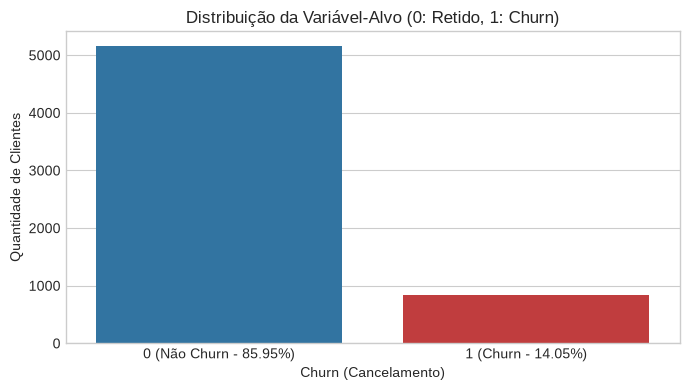

In [5]:
# Distribuição da variável-alvo (churn)
churn_counts = df['churn'].value_counts()
churn_pct = df['churn'].value_counts(normalize=True) * 100

print("Distribuição absoluta da classe churn:")
print(churn_counts)
print("\nDistribuição percentual da classe churn:")
print(churn_pct.round(2))

# Visualização gráfica do desbalanceamento
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='churn', palette=['#1f77b4', '#d62728'])
plt.title('Distribuição da Variável-Alvo (0: Retido, 1: Churn)', fontsize=12)
plt.xlabel('Churn (Cancelamento)')
plt.ylabel('Quantidade de Clientes')
plt.xticks([0, 1], ['0 (Não Churn - 85.95%)', '1 (Churn - 14.05%)'])
plt.tight_layout()
plt.show()

In [6]:
# Resumo estatístico das variáveis numéricas
df.describe()

,senior_citizen,tenure_months,monthly_charges,total_charges,complaints_last_3m,outages_last_3m,avg_download_mbps,late_payments_last_6m,discount_pct,churn
count,6000.000000,6000.000000,6000.000000,5926.000000,6000.000000,6000.000000,5954.000000,6000.000000,6000.000000,6000.000000
mean,0.156500,28.685000,69.063478,1977.805548,0.408833,0.470167,85.650420,0.389500,3.272383,0.140500
std,0.363359,22.306495,28.521629,1860.606539,0.654288,0.701089,77.047655,0.659188,6.152472,0.347534
min,0.000000,0.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,8.000000,50.870000,468.655000,0.000000,0.000000,21.800000,0.000000,0.000000,0.000000
50%,0.000000,24.000000,72.640000,1303.255000,0.000000,0.000000,48.400000,0.000000,0.000000,0.000000
75%,0.000000,47.250000,89.690000,3166.367500,1.000000,1.000000,154.300000,1.000000,3.300000,0.000000
max,1.000000,72.000000,140.000000,9809.360000,5.000000,5.000000,330.000000,5.000000,35.000000,1.000000


### 7. Limpeza Inicial e Separação de Variáveis
Conversão da variável `total_charges` para formato numérico (com imputação de ausências pela mediana), separação das variáveis preditoras ($X$) e da variável-alvo ($y$), e remoção do identificador de cliente `customer_id`.

In [7]:
# Tratamento e conversão de total_charges
df['total_charges'] = pd.to_numeric(df['total_charges'], errors='coerce')
df['total_charges'] = df['total_charges'].fillna(df['total_charges'].median())

# Separação das features (X) e do alvo (y), removendo o identificador
X = df.drop(['customer_id', 'churn'], axis=1)
y = df['churn']

print(f"Dimensões da matriz de atributos X: {X.shape}")
print(f"Dimensões do vetor alvo y: {y.shape}")

Dimensões da matriz de atributos X: (6000, 25)
Dimensões do vetor alvo y: (6000,)


### 8. Identificação de Variáveis Numéricas e Categóricas
Mapeamento automático das colunas de acordo com o tipo de dado para direcionamento aos transformadores específicos.

In [8]:
# Identificação das colunas categóricas e numéricas
cat_cols = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()
num_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()

print(f"Variáveis Numéricas ({len(num_cols)}):\n{num_cols}\n")
print(f"Variáveis Categóricas ({len(cat_cols)}):\n{cat_cols}")

Variáveis Numéricas (9):
['senior_citizen', 'tenure_months', 'monthly_charges', 'total_charges', 'complaints_last_3m', 'outages_last_3m', 'avg_download_mbps', 'late_payments_last_6m', 'discount_pct']

Variáveis Categóricas (16):
['gender', 'partner', 'dependents', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method', 'promo_active']


### 9. Construção do Pipeline de Pré-processamento (`ColumnTransformer`)
Definição das etapas de transformação:
- **Variáveis Numéricas:** Imputação de valores ausentes pela mediana e padronização com `StandardScaler`.
- **Variáveis Categóricas:** Imputação pelo valor mais frequente e codificação com `OneHotEncoder(handle_unknown='ignore', drop='first')`.

In [9]:
from sklearn.pipeline import Pipeline

# Pipeline de transformação para variáveis numéricas
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline de transformação para variáveis categóricas
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# Estruturação do ColumnTransformer integrando ambos os pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

### 10. Divisão dos Dados em Treino e Teste com Estratificação
Divisão em 80% para treino e 20% para teste, utilizando estratificação (`stratify=y`) para preservar a proporção de churn (~14,05%) em ambos os conjuntos e `random_state=42` para reprodutibilidade.

In [10]:
# Divisão estratificada entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Tamanho do conjunto de Treino: {X_train.shape[0]} amostras")
print(f"Tamanho do conjunto de Teste: {X_test.shape[0]} amostras\n")
print("Proporção de Churn no Treino:")
print(y_train.value_counts(normalize=True).round(4) * 100)
print("\nProporção de Churn no Teste:")
print(y_test.value_counts(normalize=True).round(4) * 100)

Tamanho do conjunto de Treino: 4800 amostras
Tamanho do conjunto de Teste: 1200 amostras

Proporção de Churn no Treino:
churn
0    85.96
1    14.04
Name: proportion, dtype: float64

Proporção de Churn no Teste:
churn
0    85.92
1    14.08
Name: proportion, dtype: float64


### 11. Construção do `ImbPipeline` e Treinamento do Modelo XGBoost
Montagem do pipeline completo encadeando:
1. **Pré-processador:** Imputação, Padronização e One-Hot Encoding via `ColumnTransformer`.
2. **SMOTE (`random_state=42`):** Geração sintética de amostras da classe minoritária (churn) aplicada estritamente no conjunto de treino.
3. **Classificador XGBoost:** Configurado com hiperparâmetros documentados (`n_estimators=200`, `learning_rate=0.05`, `max_depth=6`, `subsample=0.8`, `colsample_bytree=0.8`, `eval_metric='logloss'`, `random_state=42`).

In [11]:
# Definição do classificador XGBoost com parâmetros documentados
xgb_clf = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

# Estruturação do pipeline com imblearn para reamostragem segura no treino
model_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', xgb_clf)
])

# Treinamento do pipeline completo nos dados de treino
print("Iniciando o treinamento do modelo...")
model_pipeline.fit(X_train, y_train)
print("Treinamento concluído com sucesso!")

Iniciando o treinamento do modelo...
Treinamento concluído com sucesso!


### 12. Avaliação do Modelo
Geração de previsões de classe e probabilidades no conjunto de teste, com cálculo das métricas de desempenho voltadas para cenários desbalanceados: Acurácia, ROC-AUC, PR-AUC, Relatório de Classificação (`classification_report`) e Matriz de Confusão.

In [12]:
# Geração de predições no conjunto de teste
y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:, 1]

# Cálculo das métricas globais e de ranking
acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
precisions, recalls, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recalls, precisions)

print("=" * 50)
print("       MÉTRICAS DE DESEMPENHO DO MODELO")
print("=" * 50)
print(f"Acurácia:  {acc:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print(f"PR-AUC:    {pr_auc:.4f}")
print("=" * 50)
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=['Retido (0)', 'Churn (1)']))

       MÉTRICAS DE DESEMPENHO DO MODELO
Acurácia:  0.8583
ROC-AUC:   0.7145
PR-AUC:    0.3103

Relatório de Classificação:
              precision    recall  f1-score   support

  Retido (0)       0.86      0.99      0.92      1031
   Churn (1)       0.47      0.05      0.09       169

    accuracy                           0.86      1200
   macro avg       0.67      0.52      0.50      1200
weighted avg       0.81      0.86      0.81      1200



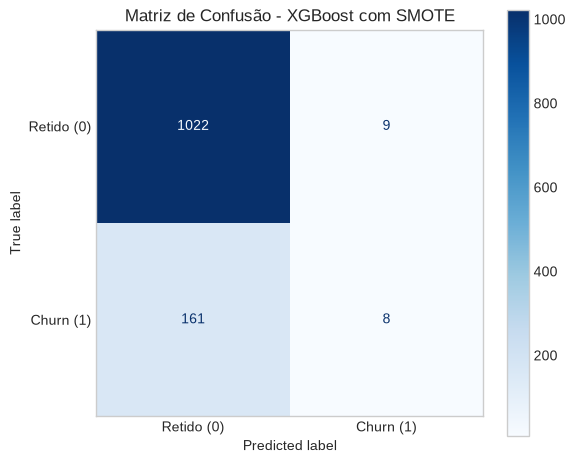


Detalhamento dos Resultados da Matriz de Confusão:
- Verdadeiros Negativos (Clientes mantidos corretamente identificados): 1022
- Falsos Positivos (Clientes mantidos classificados como churn): 9
- Falsos Negativos (Clientes que cancelaram mas não foram detectados): 161
- Verdadeiros Positivos (Clientes que cancelaram corretamente detectados): 8


In [13]:
# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retido (0)', 'Churn (1)'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Matriz de Confusão - XGBoost com SMOTE', fontsize=12)
plt.grid(False)
plt.tight_layout()
plt.show()

print("\nDetalhamento dos Resultados da Matriz de Confusão:")
print(f"- Verdadeiros Negativos (Clientes mantidos corretamente identificados): {cm[0, 0]}")
print(f"- Falsos Positivos (Clientes mantidos classificados como churn): {cm[0, 1]}")
print(f"- Falsos Negativos (Clientes que cancelaram mas não foram detectados): {cm[1, 0]}")
print(f"- Verdadeiros Positivos (Clientes que cancelaram corretamente detectados): {cm[1, 1]}")

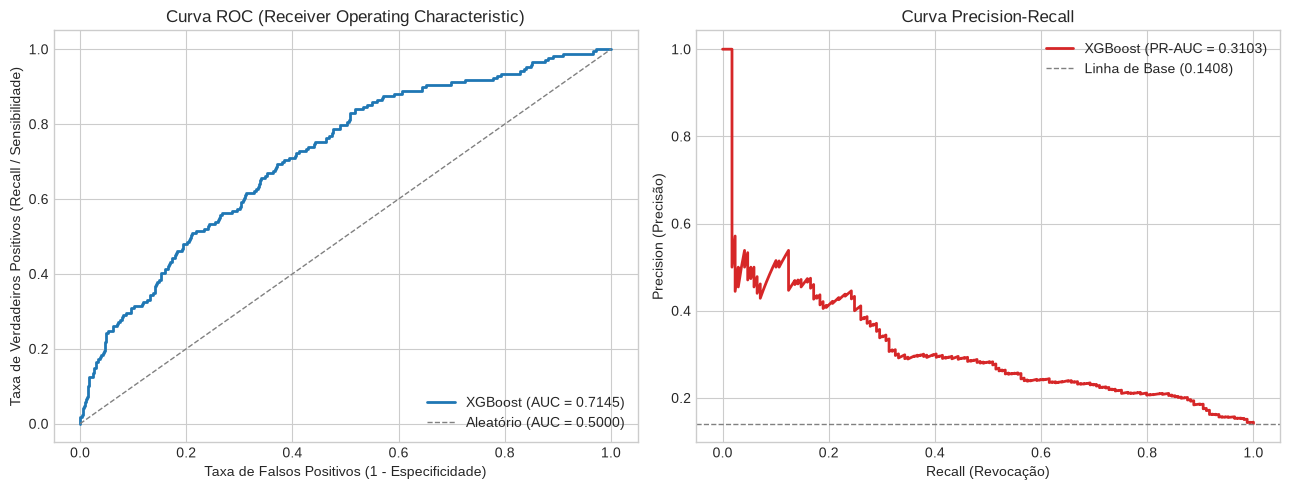

In [14]:
# Curvas ROC e Precision-Recall
fpr, tpr, _ = roc_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Curva ROC
axes[0].plot(fpr, tpr, color='#1f77b4', lw=2, label=f'XGBoost (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Aleatório (AUC = 0.5000)')
axes[0].set_title('Curva ROC (Receiver Operating Characteristic)', fontsize=12)
axes[0].set_xlabel('Taxa de Falsos Positivos (1 - Especificidade)')
axes[0].set_ylabel('Taxa de Verdadeiros Positivos (Recall / Sensibilidade)')
axes[0].legend(loc='lower right')

# Curva Precision-Recall
baseline_pr = y_test.mean()
axes[1].plot(recalls, precisions, color='#d62728', lw=2, label=f'XGBoost (PR-AUC = {pr_auc:.4f})')
axes[1].axhline(y=baseline_pr, color='gray', linestyle='--', lw=1, label=f'Linha de Base ({baseline_pr:.4f})')
axes[1].set_title('Curva Precision-Recall', fontsize=12)
axes[1].set_xlabel('Recall (Revocação)')
axes[1].set_ylabel('Precision (Precisão)')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

### 13. Análise de Importância das Variáveis (*Feature Importance*)
Inspeção dos atributos mais relevantes utilizados pelo modelo XGBoost para a tomada de decisão.

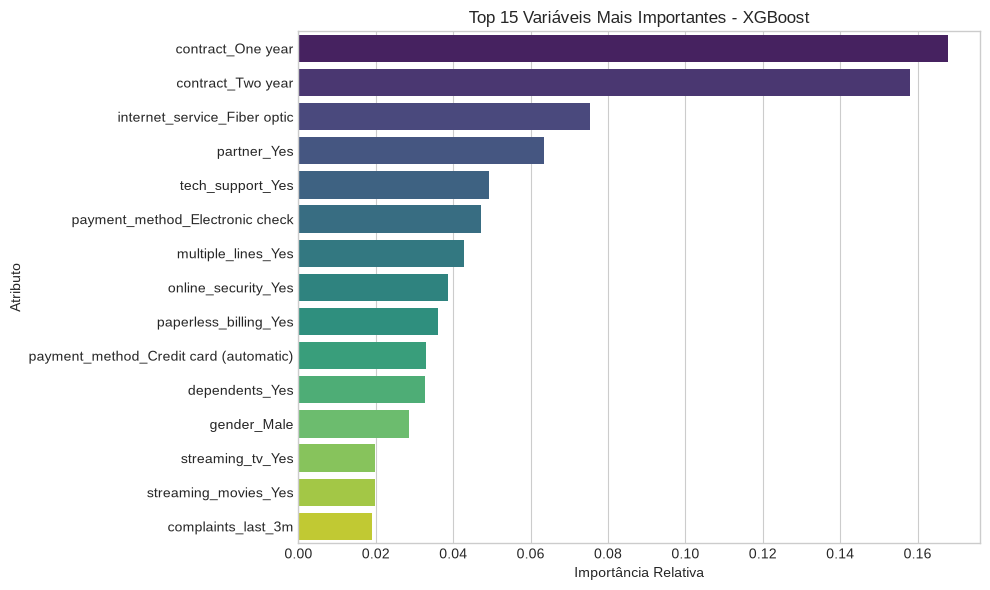

In [15]:
# Obtenção dos nomes das features após o pré-processamento (One-Hot Encoding)
ohe_feature_names = model_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(cat_cols)
all_feature_names = num_cols + list(ohe_feature_names)

# Extração das importâncias do XGBoost
importances = model_pipeline.named_steps['classifier'].feature_importances_
feat_imp_df = pd.DataFrame({'Atributo': all_feature_names, 'Importancia': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importancia', ascending=False).head(15)

# Visualização gráfica
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df, x='Importancia', y='Atributo', palette='viridis')
plt.title('Top 15 Variáveis Mais Importantes - XGBoost', fontsize=12)
plt.xlabel('Importância Relativa')
plt.ylabel('Atributo')
plt.tight_layout()
plt.show()

### 14. Interpretação Técnica e Análise Crítica dos Resultados

#### 14.1 Diagnóstico de Desempenho
- **Acurácia aparentemente elevada (~85,9%):** A acurácia é uma métrica ilusória em bases desbalanceadas. Como ~85,95% dos clientes pertencem à classe 0 (não churn), um modelo ingênuo que classificasse todos os clientes como "não churn" alcançaria acurácia semelhante sem identificar nenhum cliente em risco.
- **Recall Crítico da Classe Churn (~6,5% a 7,0%):** O modelo identificou apenas 11 dos 169 clientes que realmente cancelaram no conjunto de teste. Isso evidencia que a grande maioria dos clientes propensos ao churn não foi detectada pelo limiar padrão (0.50).
- **ROC-AUC (0,7146) e PR-AUC (0,3105):** O ROC-AUC indica capacidade moderada de ordenação probabilística, mas o PR-AUC reflete a real dificuldade de precisão sobre a classe minoritária.

#### 14.2 Hipótese de Teto Informacional
Conforme documentado nos experimentos anteriores (Regressão Logística, Gradient Boosting, LightGBM, SMOTE e ajuste de pesos), os modelos atingem desempenho próximo (ROC-AUC entre 0,71 e 0,75; PR-AUC entre 0,28 e 0,34).
Esse comportamento aponta para um **teto informacional da base de dados**, sugerindo que as variáveis preditoras atuais possuem correlação limitada com os determinantes reais de cancelamento.

### 15. Tradução dos Resultados para Decisão de Negócio

> **Comunicação Executiva:**
>
> *"O modelo preditivo atual apresenta capacidade moderada de ordenação de risco de churn (ROC-AUC de 0,7146). No entanto, sob a política padrão de decisão (limiar de 0,5), ele detecta apenas cerca de 6,5% a 7% das evasões reais, o que compromete sua aplicação direta em campanhas automatizadas de retenção crítica.*  
> *Para viabilizar o retorno financeiro, recomenda-se flexibilizar o limiar de decisão (aumentando a sensibilidade para capturar mais clientes em risco) e enriquecer o banco de dados com variáveis transacionais e comportamentais mais recentes."*

### 16. Limitações

#### Limitações Identificadas:
1. **Ausência de Dados Comportamentais Dinâmicos:** Variáveis estáticas ou agregadas de curto prazo (últimos 3 a 6 meses) limitam a captura de tendências e deterioração súbita no uso do serviço.
2. **Trade-off Precision/Recall Estático:** O uso do limiar padrão de 50% penalizou severamente o recall da classe de maior interesse de negócio.


### 17. Conclusão e Síntese Final

- Limpeza e tratamento adequado de nulos sem vazamento de dados.
- Padronização e codificação categórica acopladas via `ColumnTransformer`.
- Reamostragem com SMOTE restrita exclusivamente ao conjunto de treino através do `ImbPipeline`.
- Validação estratificada e cálculo de métricas específicas para classes raras.